In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/ecommerce.csv")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [ ]:
# Membuat Feature Engineering

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["MonthNumber"] = df["InvoiceDate"].dt.month
df["DayName"] = df["InvoiceDate"].dt.day_name()
df["DayNumber"] = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df_clean = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,YearMonth,MonthName,MonthNumber,DayName,DayNumber,Hour,TotalAmount
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2011-05,May,5,Wednesday,2,17,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,2011-07,July,7,Sunday,6,11,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,2011-07,July,7,Tuesday,1,12,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,2011-07,July,7,Wednesday,2,11,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2011-02,February,2,Sunday,6,12,2.55


In [ ]:
df_clean.nunique()

,0
InvoiceNo,3804
StockCode,1773
Description,1807
Quantity,68
InvoiceDate,3757
UnitPrice,118
CustomerID,1932
Country,31
YearMonth,13
MonthName,12


## Pertanyaan

1. Bagaimana tren total pendapatan berdasarkan bulan di tahun 2011?

In [ ]:
df_clean[df_clean["InvoiceDate"].dt.year == 2011]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,YearMonth,MonthName,MonthNumber,DayName,DayNumber,Hour,TotalAmount
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2011-05,May,5,Wednesday,2,17,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,2011-07,July,7,Sunday,6,11,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,2011-07,July,7,Tuesday,1,12,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,2011-07,July,7,Wednesday,2,11,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2011-02,February,2,Sunday,6,12,2.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,571883,23263,SET OF 3 WOODEN HEART DECORATIONS,1,2011-10-19 13:58:00,1.25,14704,United Kingdom,2011-10,October,10,Wednesday,2,13,1.25
4866,545530,21922,UNION STRIPE WITH FRINGE HAMMOCK,12,2011-03-03 13:45:00,6.95,17416,United Kingdom,2011-03,March,3,Thursday,3,13,83.40
4867,540458,21125,SET 6 FOOTBALL CELEBRATION CANDLES,12,2011-01-07 12:28:00,1.25,12501,Germany,2011-01,January,1,Friday,4,12,15.00
4868,574289,22999,TRAVEL CARD WALLET VINTAGE LEAF,24,2011-11-03 15:16:00,0.42,17750,United Kingdom,2011-11,November,11,Thursday,3,15,10.08


In [ ]:
df_2011 = df_clean[df_clean["InvoiceDate"].dt.year == 2011]

In [ ]:
df_2011.groupby("MonthName")["TotalAmount"].sum()

,TotalAmount
MonthName,
April,6357.63
August,9904.91
December,5496.43
February,6152.46
January,6247.52
July,7569.27
June,7203.93
March,7162.64
May,6987.24


In [ ]:
monthly_sales = df_2011.groupby(["MonthNumber", "MonthName"])["TotalAmount"].sum().reset_index()

In [ ]:
monthly_sales

,MonthNumber,MonthName,TotalAmount
0,1,January,6247.52
1,2,February,6152.46
2,3,March,7162.64
3,4,April,6357.63
4,5,May,6987.24
5,6,June,7203.93
6,7,July,7569.27
7,8,August,9904.91
8,9,September,9761.11
9,10,October,10177.38


Text(0, 0.5, 'Total Pendapatan ($)')

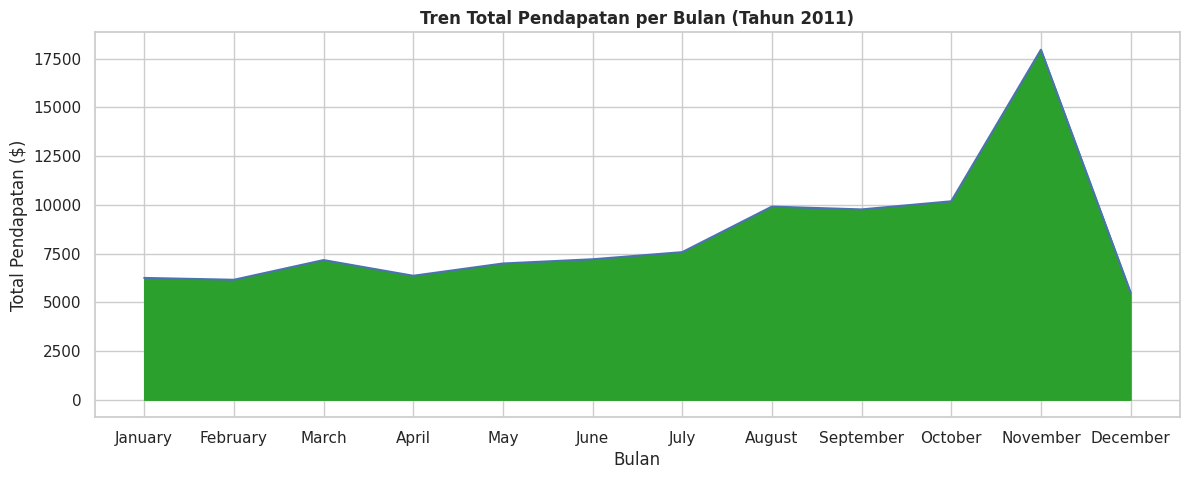

In [ ]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14,5))
sns.lineplot(data=monthly_sales, x="MonthName", y="TotalAmount")
ax.fill_between(x=monthly_sales["MonthName"], y1=monthly_sales["TotalAmount"], color='tab:green')
plt.title("Tren Total Pendapatan per Bulan (Tahun 2011)",
          fontsize=12,
          fontweight="bold"
)
plt.xlabel("Bulan")
plt.ylabel("Total Pendapatan ($)")

Pendapatan perusahaan cenderung stabil dan bergerak flat di kisaran 5,000 hingga 7,500 dollar per bulan. Mulai bulan Agustus, terjadi kenaikan pendapatan, dimana pendapatan naik dan tertahan secara konsisten di angka mendekati 10,000 dollar. Bulan November 2011 menjadi periode dengan pendapatan tertinggi sepanjang tahun, melonjak tajam hingga hampir menyentuh 18,000 dollar

2. Bagaimana perbandingan jumlah transaksi antara Hari Kerja (Weekday) vs Akhir Pekan (Weekend) setiap bulannya?

In [ ]:
df_2011.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4549 entries, 0 to 4869
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4549 non-null   int64         
 1   StockCode    4549 non-null   object        
 2   Description  4549 non-null   object        
 3   Quantity     4549 non-null   int64         
 4   InvoiceDate  4549 non-null   datetime64[ns]
 5   UnitPrice    4549 non-null   float64       
 6   CustomerID   4549 non-null   int64         
 7   Country      4549 non-null   object        
 8   YearMonth    4549 non-null   period[M]     
 9   MonthName    4549 non-null   object        
 10  MonthNumber  4549 non-null   int32         
 11  DayName      4549 non-null   object        
 12  DayNumber    4549 non-null   int32         
 13  Hour         4549 non-null   int32         
 14  TotalAmount  4549 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int32(3), int64(3), object

In [ ]:
df_2011.groupby(["DayNumber", "DayName"]).size().reset_index(name="Jumlah_Transaksi")

,DayNumber,DayName,Jumlah_Transaksi
0,0,Monday,737
1,1,Tuesday,793
2,2,Wednesday,786
3,3,Thursday,910
4,4,Friday,633
5,6,Sunday,690


Berdasarkan hasil eksplorasi diatas, ditemukan karakteristik unik bahwa dataset ini tidak mencatatkan transaksi sama sekali pada hari Sabtu (Saturday) di sepanjang tahun 2011. Oleh karena itu, seluruh volume transaksi pada kategori Weekend murni hanya direpresentasikan oleh aktivitas belanja pelanggan pada hari Minggu (Sunday).

In [ ]:
df_2011["DayType"] = df_2011["DayNumber"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")

/tmp/ipykernel_741/3786050904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2011["DayType"] = df_2011["DayNumber"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")


In [ ]:
df_2011

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,YearMonth,MonthName,MonthNumber,DayName,DayNumber,Hour,TotalAmount,DayType
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2011-05,May,5,Wednesday,2,17,2.08,Weekday
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,2011-07,July,7,Sunday,6,11,5.10,Weekend
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,2011-07,July,7,Tuesday,1,12,1.65,Weekday
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,2011-07,July,7,Wednesday,2,11,15.00,Weekday
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2011-02,February,2,Sunday,6,12,2.55,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,571883,23263,SET OF 3 WOODEN HEART DECORATIONS,1,2011-10-19 13:58:00,1.25,14704,United Kingdom,2011-10,October,10,Wednesday,2,13,1.25,Weekday
4866,545530,21922,UNION STRIPE WITH FRINGE HAMMOCK,12,2011-03-03 13:45:00,6.95,17416,United Kingdom,2011-03,March,3,Thursday,3,13,83.40,Weekday
4867,540458,21125,SET 6 FOOTBALL CELEBRATION CANDLES,12,2011-01-07 12:28:00,1.25,12501,Germany,2011-01,January,1,Friday,4,12,15.00,Weekday
4868,574289,22999,TRAVEL CARD WALLET VINTAGE LEAF,24,2011-11-03 15:16:00,0.42,17750,United Kingdom,2011-11,November,11,Thursday,3,15,10.08,Weekday


In [ ]:
cross_day_type = pd.crosstab(
    index=df_2011["MonthName"],
    columns=df_2011["DayType"]).reindex(monthly_sales["MonthName"]
)

cross_day_type

DayType,Weekday,Weekend
MonthName,,
January,218,39
February,233,36
March,291,49
April,247,32
May,296,52
June,266,36
July,261,60
August,278,47
September,421,76


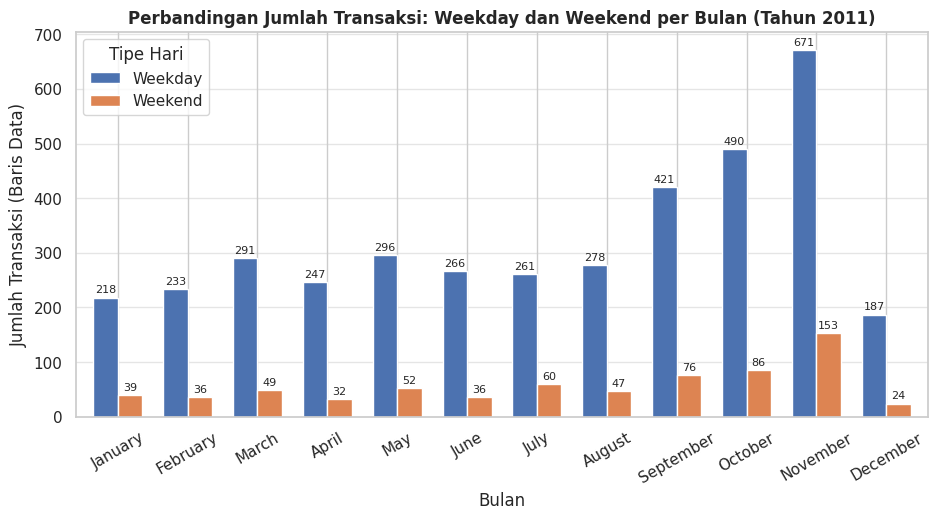

In [ ]:
sns.set_theme(style="whitegrid")
ax = cross_day_type.plot(kind='bar',
                         figsize=(11, 5),
                         width=0.7
)

ax.bar_label(ax.containers[0], padding=2, fontsize=8)
ax.bar_label(ax.containers[1], padding=2, fontsize=8)

plt.title("Perbandingan Jumlah Transaksi: Weekday dan Weekend per Bulan (Tahun 2011)",
          fontsize=12,
          fontweight="bold"
)

plt.xlabel("Bulan")
plt.ylabel("Jumlah Transaksi (Baris Data)")
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.5)
plt.legend(title="Tipe Hari")

- Pola kurva dominasi ini mengindikasikan bahwa karakteristik dasar konsumen tipe pelanggan grosir/perusahaan atau pedagang retail mandiri yang melakukan restok barang dagangan pada hari operasional kerja mereka (Senin sampai Jumat).
- Terjadi lonjakan sangat masif di kuarter keempat (September - November). jumlah transaksi weekday meroket tajam dari 421 transaksi (September) ke 671 transaksi (November)

3. Bagaimana pola kepadatan jumlah transaksi bulanan berdasarkan jam belanjanya?

In [ ]:
df_2011.pivot_table(
    index='MonthName',
    columns='Hour',
    values='InvoiceNo',
    aggfunc='nunique'
).fillna(0).reindex(monthly_sales['MonthName'])

Hour,7,8,9,10,11,12,13,14,15,16,17,18,19,20
MonthName,,,,,,,,,,,,,,
January,0.0,0.0,18.0,25.0,31.0,50.0,34.0,23.0,26.0,7.0,4.0,1.0,0.0,0.0
February,1.0,2.0,18.0,25.0,24.0,36.0,32.0,36.0,21.0,7.0,5.0,2.0,1.0,0.0
March,0.0,10.0,21.0,28.0,36.0,52.0,42.0,38.0,27.0,14.0,4.0,3.0,2.0,1.0
April,1.0,9.0,17.0,27.0,27.0,38.0,32.0,43.0,16.0,13.0,5.0,3.0,2.0,0.0
May,1.0,12.0,16.0,38.0,43.0,47.0,35.0,29.0,21.0,13.0,13.0,3.0,5.0,1.0
June,1.0,10.0,15.0,21.0,31.0,44.0,36.0,31.0,25.0,11.0,9.0,2.0,5.0,1.0
July,0.0,4.0,19.0,27.0,34.0,56.0,43.0,23.0,23.0,9.0,14.0,5.0,1.0,0.0
August,0.0,3.0,9.0,28.0,32.0,42.0,35.0,35.0,40.0,12.0,13.0,4.0,1.0,1.0
September,0.0,6.0,22.0,35.0,40.0,71.0,61.0,56.0,53.0,22.0,7.0,2.0,2.0,0.0


In [ ]:
monthly_hour_pivot = df_2011.pivot_table(
    index='MonthName',
    columns='Hour',
    values='InvoiceNo',
    aggfunc='nunique'
).fillna(0).reindex(monthly_sales['MonthName'])

Text(116.24999999999999, 0.5, 'Bulan')

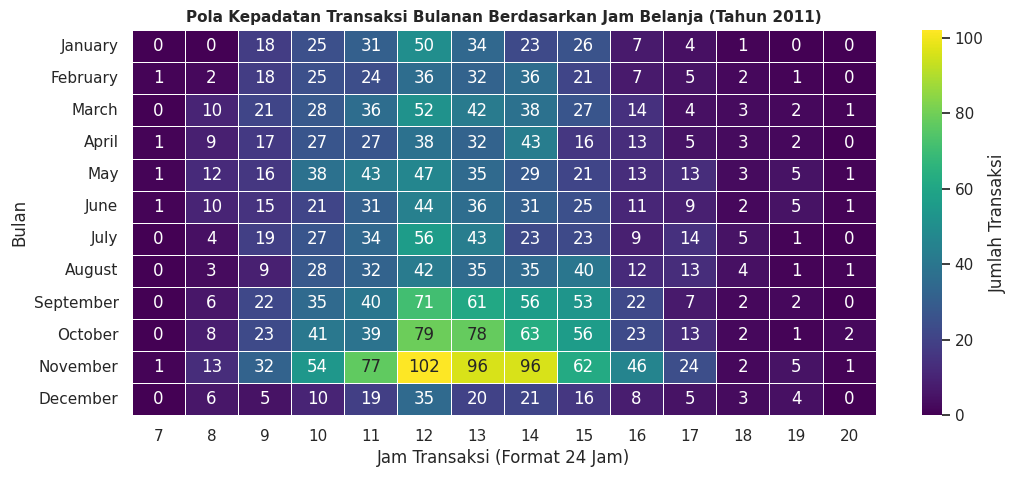

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    monthly_hour_pivot,
    cmap='viridis',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Jumlah Transaksi'}
)

plt.title("Pola Kepadatan Transaksi Bulanan Berdasarkan Jam Belanja (Tahun 2011)", fontsize=11, fontweight="bold")
plt.xlabel("Jam Transaksi (Format 24 Jam)")
plt.ylabel("Bulan")

- Berdasarkan visualisasi heatmap diatas, terlihat bahwa aktivitas transaksi meningkat pada pagi hingga siang hari, kemudian mencapai puncak pada jam 11.00 hingga 13.00 dengan transaksi tertinggi sekitar pukul 12.00. Setelah jam 16.00, aktivitas mulai menurun secara bertahap hingga mendekati nol pada malam hari
- Hasil analisis menunjukkan bahwa titik transaksi tertinggi sepanjang tahun 2011 terjadi pada bulan November pukul 12.00 dengan total 102 transaksi. Periode bulan Oktober hingga November pada jam 11.00 samapai 14.00 menjadi waktu dengan aktivitas paling padat, yang kemungkinan dipengaruhi oleh peningkatan belanja menjelang akhir tahun serta kebiasaan pelanggan melakukan transaksi saat jam istirahat di waktu siang

4. Berapa rata2 nominal uang yang dihabiskan pelanggan sekali belanja disetiap hari weekday dan weekend?

In [ ]:
pd.crosstab(
    index=df_2011['MonthName'],
    columns=df_2011['DayType'],
    values=df_2011['TotalAmount'],
    aggfunc='mean'
).reindex(monthly_sales['MonthName'])

DayType,Weekday,Weekend
MonthName,,
January,26.696422,10.966667
February,23.954549,15.862500
March,23.135395,8.780408
April,24.343320,10.775937
May,20.328480,18.654038
June,23.794361,24.295278
July,24.365479,20.164667
August,31.878525,22.184681
September,21.179382,11.113026


In [ ]:
cross_day_hitung = pd.crosstab(
    index=df_2011['MonthName'],
    columns=df_2011['DayType'],
    values=df_2011['TotalAmount'],
    aggfunc='mean'
).reindex(monthly_sales['MonthName'])

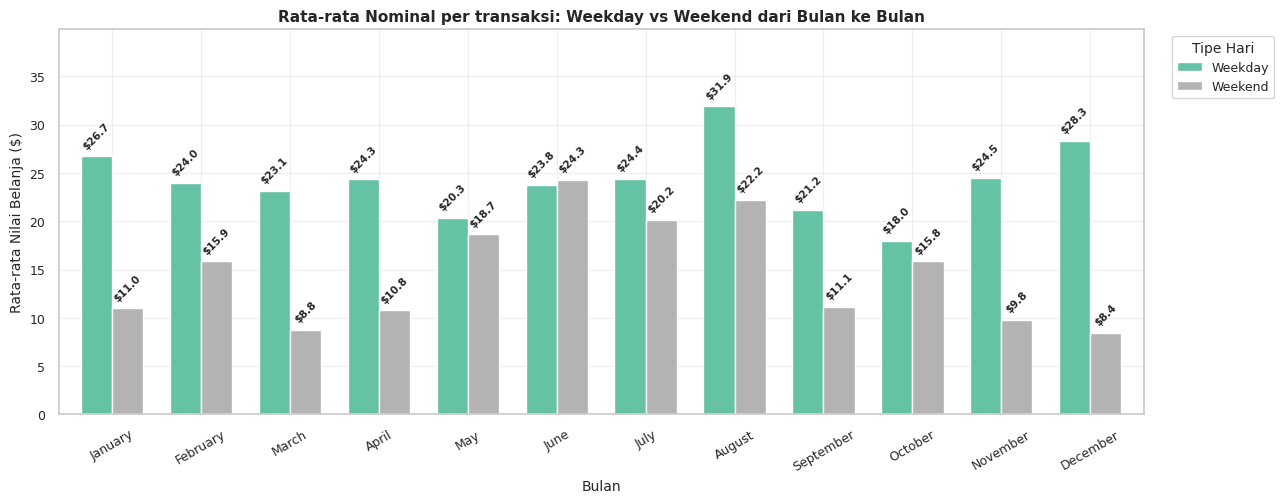

In [ ]:
ax = cross_day_hitung.plot(
    kind='bar',
    figsize=(14, 5),
    width=0.7,
    cmap='Set2'
)

ax.bar_label(ax.containers[0], fmt='$%.1f', padding=4, fontsize=7.5, fontweight='semibold', rotation=45)
ax.bar_label(ax.containers[1], fmt='$%.1f', padding=4, fontsize=7.5, fontweight='semibold', rotation=45)

plt.title("Rata-rata Nominal per transaksi: Weekday vs Weekend dari Bulan ke Bulan", fontsize=11, fontweight="bold")
plt.xlabel("Bulan", fontsize=10)
plt.ylabel("Rata-rata Nilai Belanja ($)", fontsize=10)
plt.xticks(rotation=30, fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, cross_day_hitung.max().max() * 1.25)
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', alpha=0.3)
plt.legend(title="Tipe Hari", title_fontsize=10, fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')

Rata-rata nominal uang yang dihabiskan pelanggan sekali belanja di hari kerja selalu lebih tinggi dibandingkan akhir pekan. Pada hari kerja nilai rata-rata transaksi tertinggi terjadi pada bulan Agustus dengan rata-rata pengeluaran sebesar $31.9 per transaksi.

5. Apakah trdapat korelasi antar variabel numerikal di dalam dataset tersebut?

In [ ]:
df_2011.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4549 entries, 0 to 4869
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4549 non-null   int64         
 1   StockCode    4549 non-null   object        
 2   Description  4549 non-null   object        
 3   Quantity     4549 non-null   int64         
 4   InvoiceDate  4549 non-null   datetime64[ns]
 5   UnitPrice    4549 non-null   float64       
 6   CustomerID   4549 non-null   int64         
 7   Country      4549 non-null   object        
 8   YearMonth    4549 non-null   period[M]     
 9   MonthName    4549 non-null   object        
 10  MonthNumber  4549 non-null   int32         
 11  DayName      4549 non-null   object        
 12  DayNumber    4549 non-null   int32         
 13  Hour         4549 non-null   int32         
 14  TotalAmount  4549 non-null   float64       
 15  DayType      4549 non-null   object        
dtypes: datetime

In [ ]:
num_col = ['Quantity', 'UnitPrice', 'Hour', 'TotalAmount', 'MonthNumber']

In [ ]:
df_2011[num_col].corr()

,Quantity,UnitPrice,Hour,TotalAmount,MonthNumber
Quantity,1.000000,-0.086874,-0.054563,0.751267,-0.012144
UnitPrice,-0.086874,1.000000,-0.012600,0.105981,-0.074463
Hour,-0.054563,-0.012600,1.000000,-0.028097,0.089777
TotalAmount,0.751267,0.105981,-0.028097,1.000000,-0.006385
MonthNumber,-0.012144,-0.074463,0.089777,-0.006385,1.000000


In [ ]:
corr_num = df_2011[num_col].corr()

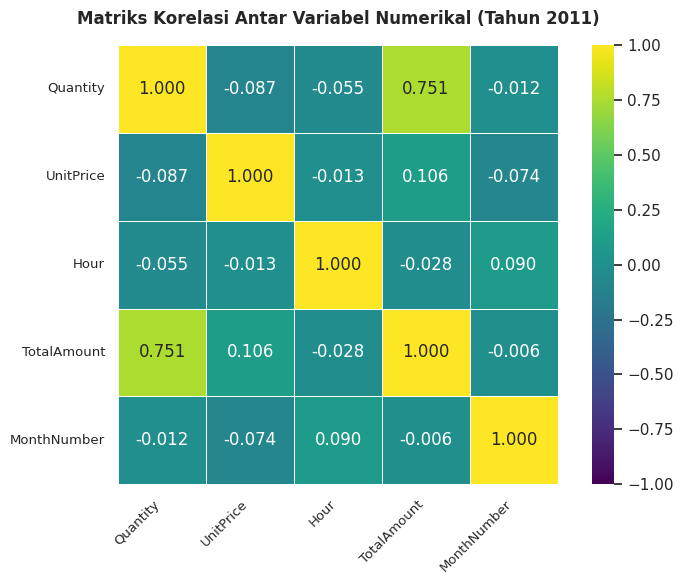

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_num,
    annot=True, fmt='.3f', cmap='viridis', vmin=-1, vmax=1,
    linewidths=0.5, square=True
)

plt.title("Matriks Korelasi Antar Variabel Numerikal (Tahun 2011)", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9.5)
plt.yticks(rotation=0, fontsize=9.5)
plt.tight_layout()
plt.show()

Berdasarkan pola matriks diatas, sebagian besar variabel numerik memiliki nilai korelasi yang rendah (mendekati 0), sehingga menunjukkan hubungan yang lemah. Korelasi paling kuat terdapat antara Quantity dan TotalAmount dengan nilai 0,751, yang menunjukkan hubungan positif yang kuat. Hal itu mengartikan bahwa semakin banyak jumlah barang yang dibeli, semakin besar nilai total transaksi. Sementara itu, variabel UnitPrice, Hour, dan MonthNumber memiliki korelasi yang sangat kecil terhadap variabel lainnya, sehingga tidak menunjukkan hubungan linear yang signifikan.